# Data-Driven Methods — Simulations

This notebook accompanies the *Data-Driven Methods* chapter. It produces all figures
illustrating the core machine learning concepts discussed in the text.

**Sections**
1. Bias-Variance Tradeoff
2. Regularisation Paths (Ridge and Lasso)
3. Classification and Decision Boundaries
4. Tree Ensembles
5. Neural Networks: Training Curves
6. Principal Component Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.decomposition import PCA
from sklearn.datasets import make_classification, make_regression, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

FIGDIR = '../markdown/figures/'

## 1. Bias-Variance Tradeoff

Polynomial regression of varying degree on a sinusoidal target, averaged over many dataset realisations.

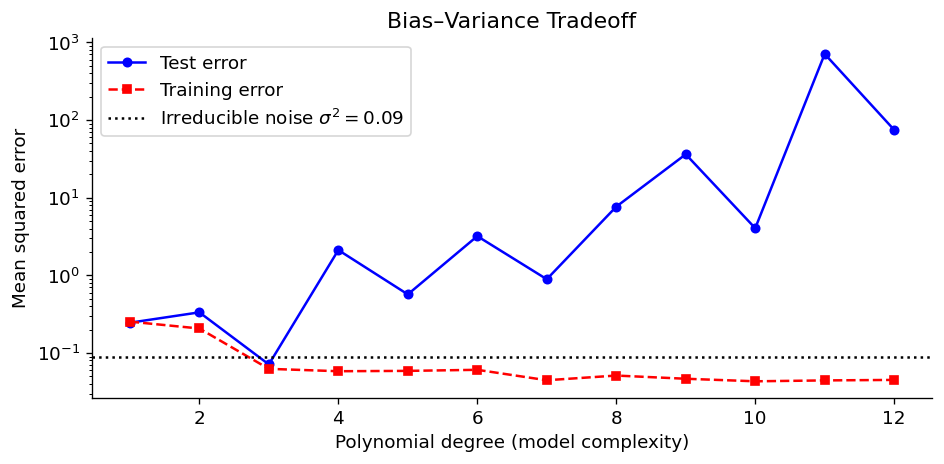

Saved ddm_bias_variance.png


In [2]:
np.random.seed(42)

x_test = np.linspace(0, 1, 200)
f_true = np.sin(2 * np.pi * x_test)
n_repeats, n_train, sigma = 50, 15, 0.3
degrees = range(1, 13)

train_errors, test_errors = [], []
for d in degrees:
    te, tr = [], []
    for _ in range(n_repeats):
        x_tr = np.random.uniform(0, 1, n_train)
        y_tr = np.sin(2 * np.pi * x_tr) + np.random.normal(0, sigma, n_train)
        pipe = make_pipeline(PolynomialFeatures(d), Ridge(alpha=1e-8))
        pipe.fit(x_tr.reshape(-1, 1), y_tr)
        te.append(np.mean((f_true - pipe.predict(x_test.reshape(-1, 1)))**2))
        tr.append(np.mean((y_tr - pipe.predict(x_tr.reshape(-1, 1)))**2))
    test_errors.append(np.mean(te))
    train_errors.append(np.mean(tr))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(degrees), test_errors, 'b-o', markersize=5, label='Test error')
ax.plot(list(degrees), train_errors, 'r--s', markersize=5, label='Training error')
ax.axhline(sigma**2, color='k', linestyle=':', linewidth=1.5, label=f'Irreducible noise $\\sigma^2={sigma**2}$')
ax.set_xlabel('Polynomial degree (model complexity)')
ax.set_ylabel('Mean squared error')
ax.set_title('Bias–Variance Tradeoff')
ax.set_yscale('log')
ax.legend()
fig.tight_layout()
fig.savefig(FIGDIR + 'ddm_bias_variance.png', bbox_inches='tight')
plt.show()
print('Saved ddm_bias_variance.png')

## 2. Regularisation Paths

Ridge and Lasso coefficient paths as a function of the log-penalty parameter $\log_{10}\lambda$.

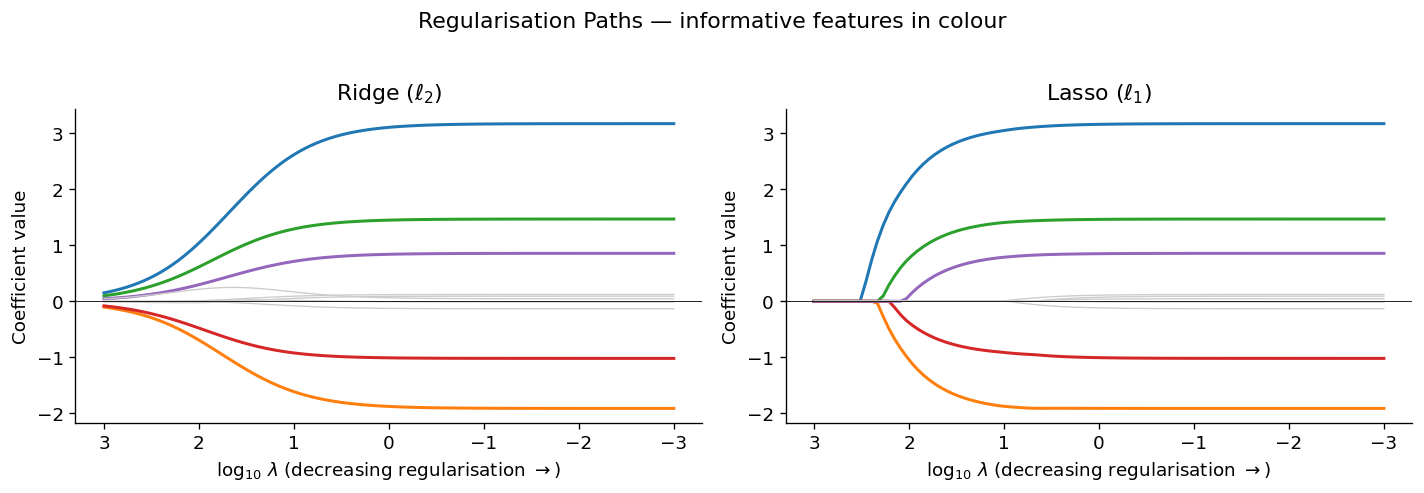

Saved ddm_regularization.png


In [3]:
np.random.seed(42)
N, D = 60, 10
X = np.random.randn(N, D)
beta_true = np.array([3.0, -2.0, 1.5, -1.0, 0.8] + [0.0]*5)
y = X @ beta_true + np.random.randn(N) * 0.5

lambdas = np.logspace(-3, 3, 100)
ridge_coefs = np.array([Ridge(alpha=lam).fit(X, y).coef_ for lam in lambdas])
lasso_coefs = np.array([Lasso(alpha=lam / (2*N), max_iter=20000).fit(X, y).coef_ for lam in lambdas])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for j in range(D):
    c = f'C{j}' if j < 5 else '#cccccc'
    lw = 1.8 if j < 5 else 0.8
    axes[0].plot(np.log10(lambdas), ridge_coefs[:, j], color=c, lw=lw)
    axes[1].plot(np.log10(lambdas), lasso_coefs[:, j], color=c, lw=lw)

for ax, title in zip(axes, ['Ridge ($\\ell_2$)', 'Lasso ($\\ell_1$)']):
    ax.axhline(0, color='k', lw=0.5)
    ax.invert_xaxis()
    ax.set_xlabel('$\\log_{10}\\,\\lambda$ (decreasing regularisation $\\rightarrow$)')
    ax.set_ylabel('Coefficient value')
    ax.set_title(title)

fig.suptitle('Regularisation Paths — informative features in colour', y=1.02)
fig.tight_layout()
fig.savefig(FIGDIR + 'ddm_regularization.png', bbox_inches='tight')
plt.show()
print('Saved ddm_regularization.png')

## 3. Classification and Decision Boundaries

Decision boundaries for logistic regression, SVM with RBF kernel, and a two-layer MLP on a 2D binary classification dataset.

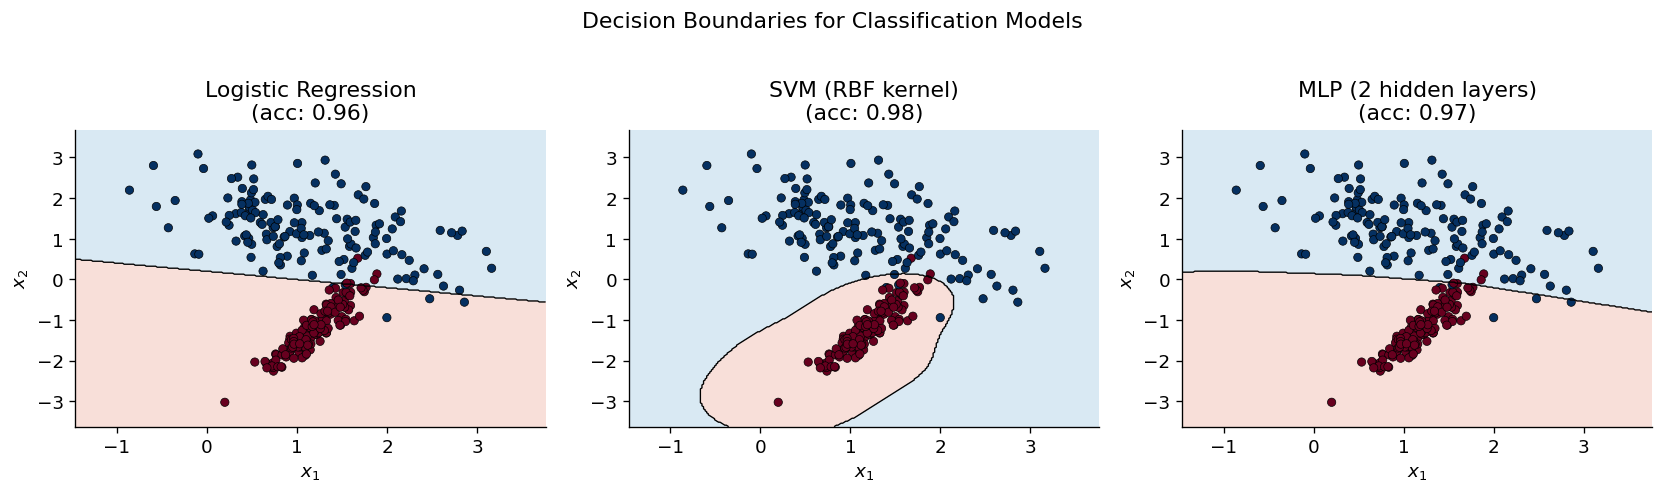

Saved ddm_decision_boundary.png


In [4]:
np.random.seed(42)
X_cl, y_cl = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                  n_informative=2, random_state=42,
                                  n_clusters_per_class=1, class_sep=1.2)

models = [
    ('Logistic Regression', LogisticRegression(C=1.0, max_iter=1000)),
    ('SVM (RBF kernel)', SVC(kernel='rbf', C=1.0, gamma=1.0)),
    ('MLP (2 hidden layers)', MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=2000, random_state=42)),
]

x0_min, x0_max = X_cl[:, 0].min() - 0.6, X_cl[:, 0].max() + 0.6
x1_min, x1_max = X_cl[:, 1].min() - 0.6, X_cl[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 300),
                     np.linspace(x1_min, x1_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, clf) in zip(axes, models):
    clf.fit(X_cl, y_cl)
    Z = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu', levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, Z, colors='k', linewidths=0.8, levels=[0.5])
    ax.scatter(X_cl[:, 0], X_cl[:, 1], c=y_cl, cmap='RdBu',
               edgecolors='k', linewidths=0.4, s=25)
    ax.set_title(f'{name}\n(acc: {clf.score(X_cl, y_cl):.2f})')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_xlim(x0_min, x0_max)
    ax.set_ylim(x1_min, x1_max)

fig.suptitle('Decision Boundaries for Classification Models', y=1.02)
fig.tight_layout()
fig.savefig(FIGDIR + 'ddm_decision_boundary.png', bbox_inches='tight')
plt.show()
print('Saved ddm_decision_boundary.png')

## 4. Tree Ensembles

Comparison of a single decision tree, random forest, and gradient-boosted ensemble on a regression problem.

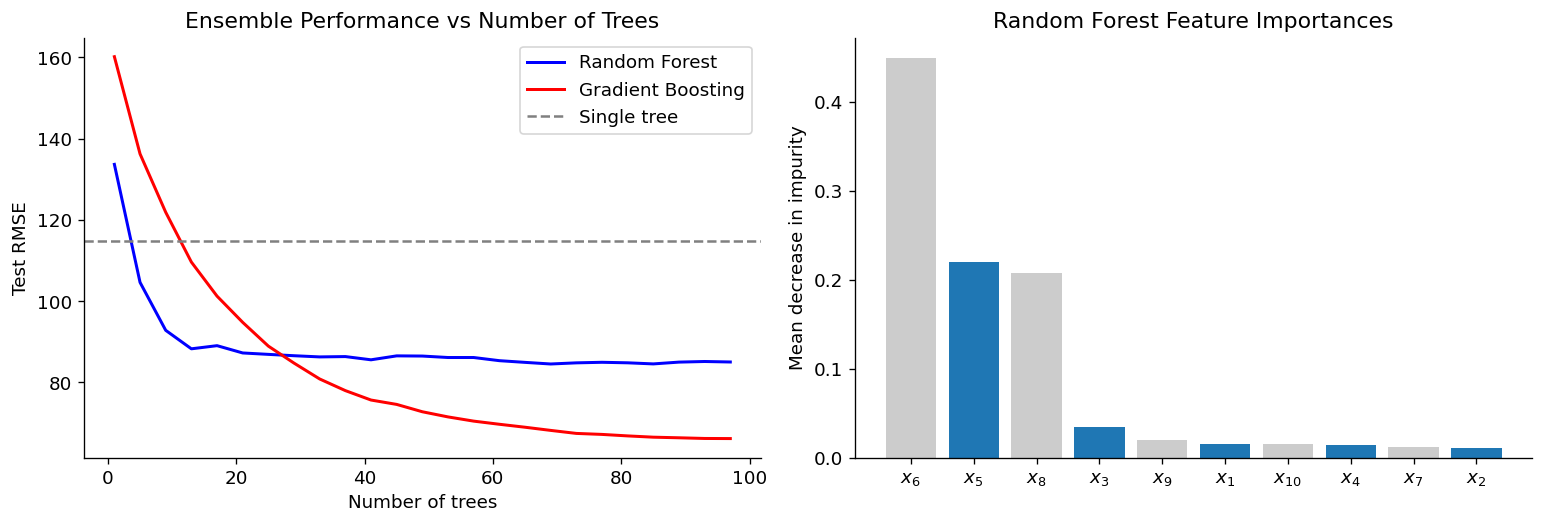

Saved ddm_trees.png


In [5]:
np.random.seed(42)
X_reg, y_reg = make_regression(n_samples=300, n_features=10, n_informative=5,
                                noise=25.0, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

n_trees_grid = list(range(1, 101, 4))
rf_rmse, gb_rmse = [], []

for n in n_trees_grid:
    rf = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    rf_rmse.append(np.sqrt(mean_squared_error(y_te, rf.predict(X_te))))

    gb = GradientBoostingRegressor(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42)
    gb.fit(X_tr, y_tr)
    gb_rmse.append(np.sqrt(mean_squared_error(y_te, gb.predict(X_te))))

tree_single = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_tr, y_tr)
tree_rmse = np.sqrt(mean_squared_error(y_te, tree_single.predict(X_te)))

rf_final = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_tr, y_tr)
importances = rf_final.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(n_trees_grid, rf_rmse, 'b-', lw=1.8, label='Random Forest')
axes[0].plot(n_trees_grid, gb_rmse, 'r-', lw=1.8, label='Gradient Boosting')
axes[0].axhline(tree_rmse, color='gray', linestyle='--', lw=1.5, label='Single tree')
axes[0].set_xlabel('Number of trees')
axes[0].set_ylabel('Test RMSE')
axes[0].set_title('Ensemble Performance vs Number of Trees')
axes[0].legend()

bar_colors = ['C0' if sorted_idx[i] < 5 else '#cccccc' for i in range(10)]
axes[1].bar(range(10), importances[sorted_idx], color=bar_colors)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([f'$x_{{{sorted_idx[i]+1}}}$' for i in range(10)])
axes[1].set_ylabel('Mean decrease in impurity')
axes[1].set_title('Random Forest Feature Importances')

fig.tight_layout()
fig.savefig(FIGDIR + 'ddm_trees.png', bbox_inches='tight')
plt.show()
print('Saved ddm_trees.png')

## 5. Neural Networks: Training Curves

Training and validation MSE for an MLP with and without $\ell_2$ weight decay, illustrating overfitting behaviour.

/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/javier/Documents/aaat/venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


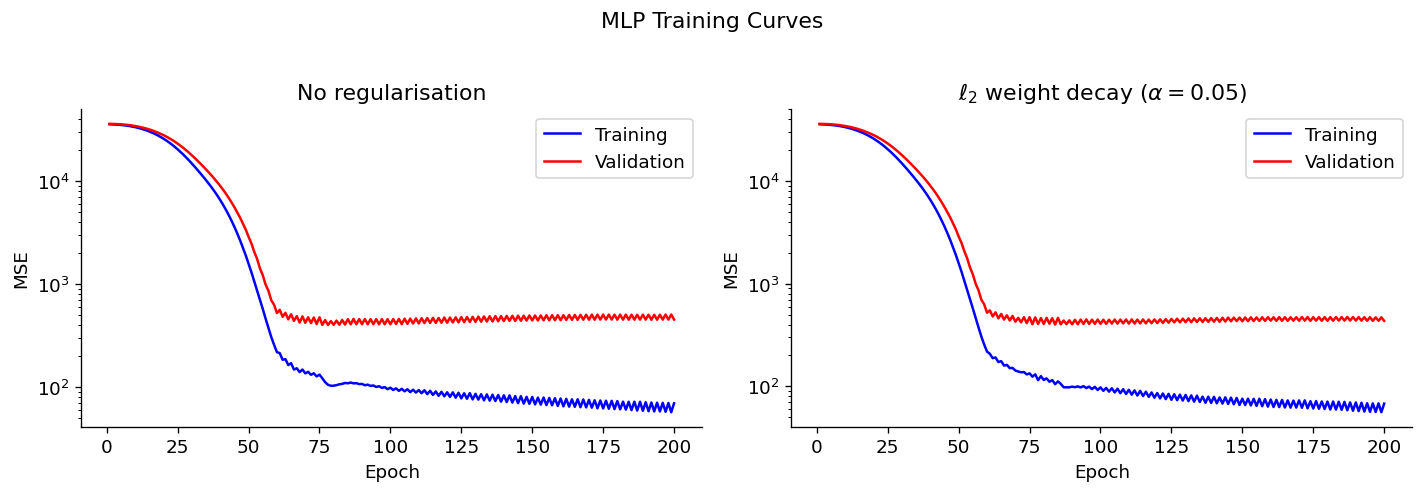

Saved ddm_nn_training.png


In [6]:
np.random.seed(42)
X_nn, y_nn = make_regression(n_samples=400, n_features=20, n_informative=10,
                              noise=10.0, random_state=42)
X_nn = X_nn / (X_nn.std(axis=0) + 1e-8)
X_nn_tr, X_nn_te, y_nn_tr, y_nn_te = train_test_split(X_nn, y_nn, test_size=0.35, random_state=42)

def train_mlp_history(X_tr, y_tr, X_te, y_te, alpha, n_epochs=200):
    tr_loss, val_loss = [], []
    model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1,
                         warm_start=True, random_state=42,
                         alpha=alpha, learning_rate_init=0.005,
                         solver='adam')
    for _ in range(n_epochs):
        model.fit(X_tr, y_tr)
        tr_loss.append(mean_squared_error(y_tr, model.predict(X_tr)))
        val_loss.append(mean_squared_error(y_te, model.predict(X_te)))
    return tr_loss, val_loss

tr_noreg, val_noreg = train_mlp_history(X_nn_tr, y_nn_tr, X_nn_te, y_nn_te, alpha=1e-10)
tr_reg,   val_reg   = train_mlp_history(X_nn_tr, y_nn_tr, X_nn_te, y_nn_te, alpha=0.05)

epochs = range(1, 201)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (tr, val, title) in zip(axes, [
    (tr_noreg, val_noreg, 'No regularisation'),
    (tr_reg,   val_reg,   '$\\ell_2$ weight decay ($\\alpha=0.05$)'),
]):
    ax.plot(epochs, tr,  'b-', lw=1.5, label='Training')
    ax.plot(epochs, val, 'r-', lw=1.5, label='Validation')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.set_yscale('log')
    ax.legend()

fig.suptitle('MLP Training Curves', y=1.02)
fig.tight_layout()
fig.savefig(FIGDIR + 'ddm_nn_training.png', bbox_inches='tight')
plt.show()
print('Saved ddm_nn_training.png')

## 6. Principal Component Analysis

PCA on a two-dimensional correlated dataset and cumulative explained variance on a ten-dimensional dataset.

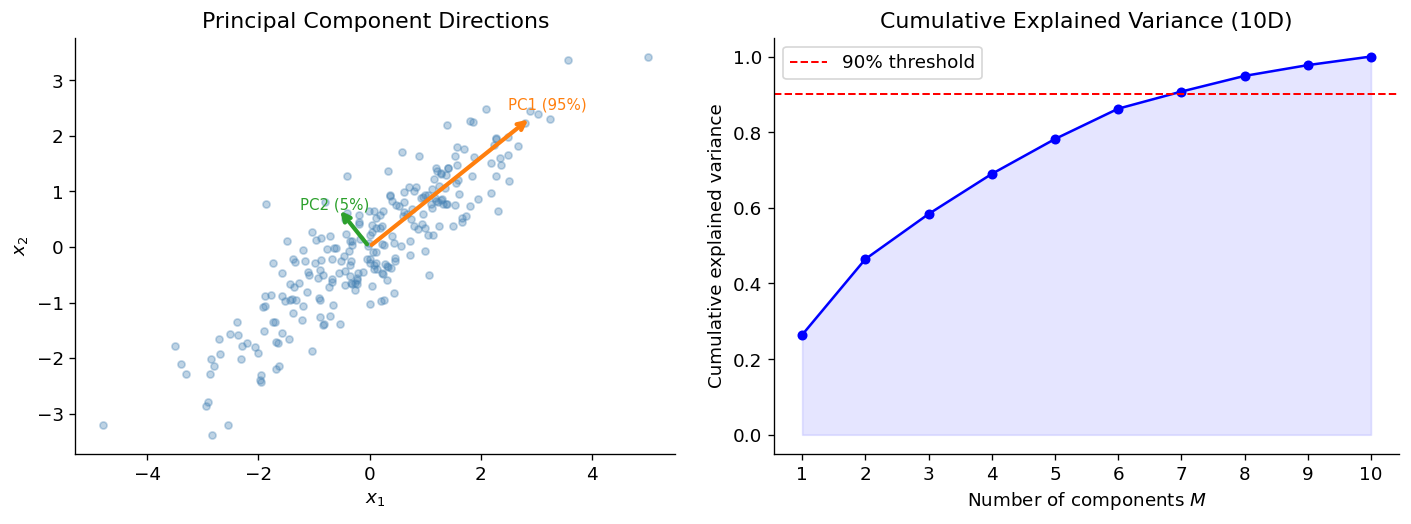

Saved ddm_pca.png


In [7]:
np.random.seed(42)

# 2D correlated dataset
cov2 = np.array([[2.2, 1.6], [1.6, 1.5]])
X_2d = np.random.multivariate_normal([0, 0], cov2, 250)
pca2 = PCA(n_components=2).fit(X_2d)

# 10D dataset with structured covariance
A = np.random.randn(10, 10)
cov10 = A @ A.T / 10 + np.eye(10) * 0.3
X_10d = np.random.multivariate_normal(np.zeros(10), cov10, 600)
pca10 = PCA().fit(X_10d)
cumvar = np.cumsum(pca10.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: scatter with PC arrows
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.35, s=18, color='steelblue')
origin = X_2d.mean(axis=0)
for i, (pc, ev) in enumerate(zip(pca2.components_, pca2.explained_variance_)):
    scale = 2.0 * ev**0.5
    axes[0].annotate('', xy=origin + scale * pc, xytext=origin,
                     arrowprops=dict(arrowstyle='->', color=f'C{i+1}', lw=2.5))
    axes[0].text(*(origin + 1.1 * scale * pc),
                 f'PC{i+1} ({pca2.explained_variance_ratio_[i]:.0%})',
                 color=f'C{i+1}', fontsize=9, ha='center', va='center')
axes[0].set_title('Principal Component Directions')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].set_aspect('equal')

# Right: cumulative explained variance
axes[1].plot(range(1, 11), cumvar, 'b-o', markersize=5)
axes[1].axhline(0.9, color='r', linestyle='--', lw=1.2, label='90% threshold')
axes[1].fill_between(range(1, 11), cumvar, alpha=0.1, color='b')
axes[1].set_xlabel('Number of components $M$')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative Explained Variance (10D)')
axes[1].set_xticks(range(1, 11))
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGDIR + 'ddm_pca.png', bbox_inches='tight')
plt.show()
print('Saved ddm_pca.png')